# EFIplus Mediterranean Dataset — PCA, PCoA and LDA

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FernandaChacara/AVCAD/blob/main/Exercise7/EFIplus_PCA_PCoA_LDA_exercise.ipynb)

> **Nota:** o botão acima funciona depois de este notebook estar guardado no GitHub no caminho:  
> `AVCAD/Exercise7/EFIplus_PCA_PCoA_LDA_exercise.ipynb`



# EFIplus Mediterranean Dataset — PCA, PCoA and LDA

This notebook solves the exercise using the dataset `EFIplus_medit.zip` / `EFIplus_medit (2).zip`.

The analysis uses only sites from the **Douro**, **Tejo**, **Mondego** and **Minho** basins, and uses `Catchment_name` as the grouping variable in all plots.

The quantitative environmental variables used are the same as in the previous exercise:

- `Altitude`
- `Actual_river_slope`
- `Elevation_mean_catch`
- `prec_ann_catch`
- `temp_ann`
- `temp_jan`
- `temp_jul`


In [1]:
# Import libraries
# These libraries are enough for PCA, PCoA, LDA, data manipulation and plotting.

import os
import zipfile
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)


In [4]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving EFIplus_medit (2).zip to EFIplus_medit (2).zip
User uploaded file "EFIplus_medit (2).zip" with length 367168 bytes


Depois de carregar o ficheiro, execute a célula que deu erro (`35ab286f`) novamente.

In [5]:
# Find the EFIplus zip file automatically.
# This avoids errors if the file is called 'EFIplus_medit.zip' or 'EFIplus_medit (2).zip'.

possible_zips = list(Path('.').glob('**/EFIplus_medit*.zip'))

if len(possible_zips) == 0:
    raise FileNotFoundError(
        "No EFIplus_medit ZIP file was found. Upload 'EFIplus_medit.zip' or 'EFIplus_medit (2).zip' and run again."
    )

zip_path = possible_zips[0]
print(f"Using ZIP file: {zip_path}")

extract_dir = Path('EFIplus_medit_extracted')
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# Show files extracted from the ZIP.
extracted_files = list(extract_dir.glob('**/*'))
[f.name for f in extracted_files if f.is_file()][:20]


Using ZIP file: EFIplus_medit (2).zip


['EFIplus_medit.csv']

In [6]:
# Read the dataset.
# The code searches for CSV/TXT files inside the extracted ZIP and reads the largest one,
# which is normally the main EFIplus dataset.

candidate_files = [f for f in extract_dir.glob('**/*') if f.suffix.lower() in ['.csv', '.txt', '.tsv']]

if len(candidate_files) == 0:
    raise FileNotFoundError("No CSV/TXT file was found inside the ZIP.")

# Choose the largest file, because it is usually the full data table.
data_file = max(candidate_files, key=lambda x: x.stat().st_size)
print(f"Reading data file: {data_file}")

# sep=None lets pandas infer whether the separator is comma, semicolon or tab.
df = pd.read_csv(data_file, sep=None, engine='python')

print(df.shape)
df.head()


Reading data file: EFIplus_medit_extracted/EFIplus_medit.csv
(5011, 164)


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,Geomorph2,Geomorph3,Water_source_type,Flow_regime,Altitude,Geological_typology,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,Barriers_catchment_down,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,Impoundment,Hydropeaking,Water_abstraction,Hydro_mod,Temperature_impact,Velocity_increase,Reservoir_flushing,Sedimentation,Channelisation,Cross_sec,Instream_habitat,Riparian_vegetation,Embankment,Floodprotection,Floodplain,Toxic_substances,Acidification,Water_quality_index,Eutrophication,Organic_pollution,Organic_siltation,Sum of Run1_number_all,Total_sp,Abramis brama,Achondrostoma arcasii,Achondrostoma occidentale,Achondrostoma oligolepis,...,Gobio lozanoi,Gymnocephalus cernuus,Hypophthalmichthys molitrix,Iberochondrostoma almacai,Iberochondrostoma lemmingii,Iberochondrostoma lusitanicum,Lampetra fluviatilis,Lampetra planeri,Lepomis gibbosus,Leuciscus cephalus,Leuciscus leuciscus,Leuciscus lucumonis,Leuciscus souffia,Liza aurata,Liza ramada,Luciobarbus guiraonis,Micropterus salmoides,Mugil cephalus,Oncorhynchus mykiss,Pachychilon pictum,Padogobius martensii,Padogobius nigricans,Parachondrostoma arrigonis,Parachondrostoma miegii,Parachondrostoma turiense,Perca fluviatilis,Petromyzon marinus,Phoxinus bigerri,Phoxinus phoxinus,Platichthys flesus,Pseudochondrostoma duriense,Pseudochondrostoma polylepis,Pseudochondrostoma willkommii,Pseudorasbora parva,Rhodeus amarus,Rutilus aula,Rutilus rubilio,Rutilus rutilus,Salaria fluviatilis,Salmo salar,Salmo trutta fario,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius alburnoides,Squalius aradensis,Squalius carolitertii,Squalius laietanus,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,1,1,-0.047266,-1.039638,0.451016,Pluvial,Permanent,199,Siliceous,0.001,3.0,700.840807,522.071164,17.6,8.5,28.1,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,1.0,1.0,1.0,1,4.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,1,1,0.389648,-0.443332,0.489422,Groundwater,Permanent,1253,Calcareous,13.406,3.0,1603.519424,640.327779,9.3,0.6,18.9,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,7,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,1,1,0.344331,-0.504929,0.485476,Groundwater,Permanent,1155,Calcareous,9.398,3.0,1578.678579,633.238847,10.1,1.2,19.6,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,45,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,1,1,0.460283,-0.485457,-1.115365,Groundwater,Permanent,1074,Calcareous,8.186,3.0,1553.219128,625.841858,10.1,1.2,19.5,3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,15,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,1,1,0.272000,-0.598013,0.479972,Groundwater,Permanent,1018,Calcareous,11.736,3.0,1539.684999,622.111415,

## 2. Select basins and quantitative environmental variables

The exercise asks for only the Douro, Tejo, Mondego and Minho basins. Missing values in the selected variables are removed because PCA, PCoA and LDA require complete numerical data.


In [7]:
# Basins required in the exercise
selected_basins = ['Douro', 'Tejo', 'Mondego', 'Minho']

# Quantitative environmental variables from the previous exercise
env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

# Check that all required columns exist before continuing.
required_cols = ['Catchment_name'] + env_vars
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"These required columns are missing from the dataset: {missing_cols}")

# Filter the dataset to the required basins only.
data = df[df['Catchment_name'].isin(selected_basins)].copy()

# Convert environmental variables to numeric, forcing problematic values to NaN.
for col in env_vars:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove rows with missing values in the variables used for the analyses.
data_clean = data.dropna(subset=required_cols).copy()

print("Original filtered data shape:", data.shape)
print("Clean data shape:", data_clean.shape)
print("Number of sites by catchment:")
display(data_clean['Catchment_name'].value_counts())

data_clean[['Site_code', 'Catchment_name'] + env_vars].head()


Original filtered data shape: (1703, 164)
Clean data shape: (1681, 164)
Number of sites by catchment:


,count
Catchment_name,
Minho,707
Tejo,493
Douro,395
Mondego,86


,Site_code,Catchment_name,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
1,ES_02_0001,Tejo,1253,13.406,1603.519424,640.327779,9.3,0.6,18.9
2,ES_02_0002,Tejo,1155,9.398,1578.678579,633.238847,10.1,1.2,19.6
3,ES_02_0003,Tejo,1074,8.186,1553.219128,625.841858,10.1,1.2,19.5
4,ES_02_0004,Tejo,1018,11.736,1539.684999,622.111415,10.3,1.7,20.0
5,ES_02_0005,Tejo,979,2.670,1493.914010,608.146170,10.6,1.8,20.2


In [8]:
# Standardise the quantitative environmental variables.
# Standardisation is important because variables are measured in different units.

X = data_clean[env_vars].values
y = data_clean['Catchment_name'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=env_vars, index=data_clean.index)
X_scaled_df.head()


,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
1,2.125767,-0.074603,1.801357,-1.082627,-1.654765,-1.930847,-0.766044
2,1.832393,-0.275873,1.738580,-1.107775,-1.287215,-1.697619,-0.461021
3,1.589910,-0.336736,1.674239,-1.134016,-1.287215,-1.697619,-0.504595
4,1.422268,-0.158465,1.640036,-1.147250,-1.195328,-1.503263,-0.286722
5,1.305517,-0.613732,1.524365,-1.196791,-1.057497,-1.464392,-0.199573


# Part 1 — PCA based on quantitative environmental variables

PCA reduces the environmental variables into synthetic axes that summarise the main environmental gradients among sites. The biplot shows both the position of sites and the contribution of each environmental variable.


In [9]:
# Run PCA with two components.

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'], index=data_clean.index)
pca_df['Catchment_name'] = y

# PCA loadings show how strongly each original variable contributes to the PCA axes.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=env_vars
)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained[0]:.2f}% of the variance")
print(f"PC2 explains {explained[1]:.2f}% of the variance")

display(loadings)


PC1 explains 60.99% of the variance
PC2 explains 21.48% of the variance


,PC1,PC2
Altitude,-0.457937,-0.178138
Actual_river_slope,-0.196760,0.309524
Elevation_mean_catch,-0.439745,-0.183194
prec_ann_catch,0.005759,0.773494
temp_ann,0.472069,-0.071176
temp_jan,0.461903,0.183610
temp_jul,0.349237,-0.449256


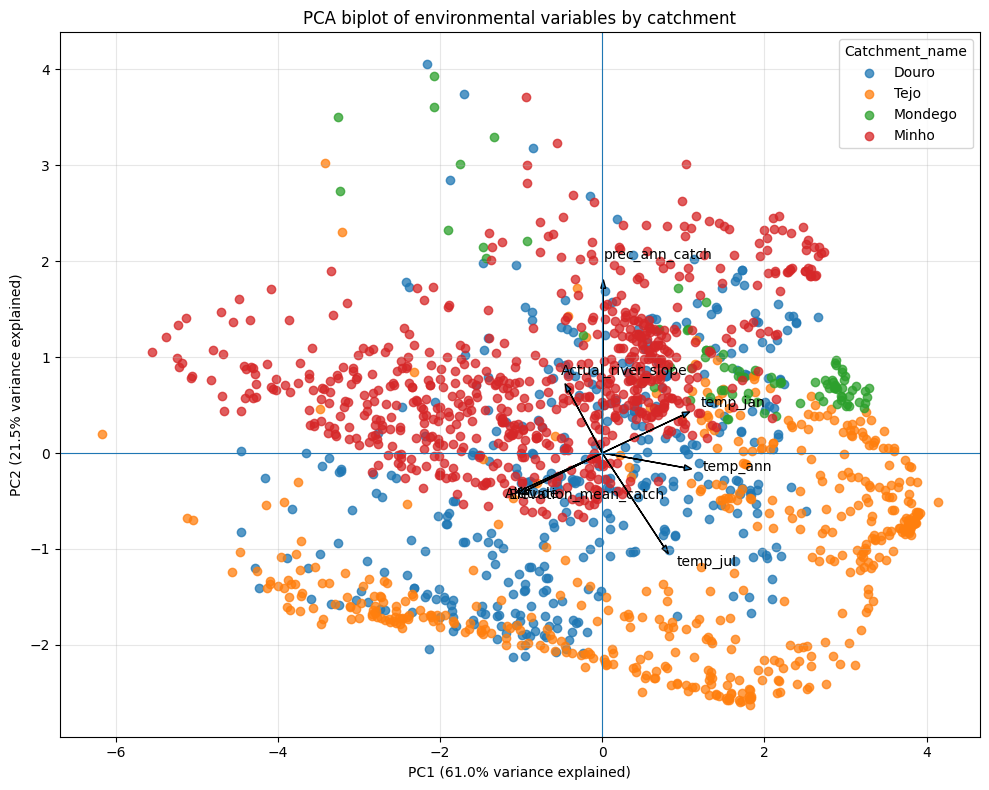

In [10]:
# PCA biplot grouped by Catchment_name.

fig, ax = plt.subplots(figsize=(10, 8))

# Plot sites by catchment.
for catchment in selected_basins:
    subset = pca_df[pca_df['Catchment_name'] == catchment]
    ax.scatter(subset['PC1'], subset['PC2'], label=catchment, alpha=0.75)

# Scale arrows so that they fit nicely in the same figure as the scores.
arrow_scale = min(
    (pca_df['PC1'].max() - pca_df['PC1'].min()),
    (pca_df['PC2'].max() - pca_df['PC2'].min())
) * 0.35

for var in env_vars:
    ax.arrow(
        0, 0,
        loadings.loc[var, 'PC1'] * arrow_scale,
        loadings.loc[var, 'PC2'] * arrow_scale,
        head_width=0.06,
        length_includes_head=True
    )
    ax.text(
        loadings.loc[var, 'PC1'] * arrow_scale * 1.12,
        loadings.loc[var, 'PC2'] * arrow_scale * 1.12,
        var,
        fontsize=10
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance explained)")
ax.set_title("PCA biplot of environmental variables by catchment")
ax.legend(title='Catchment_name')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_biplot_catchment.png', dpi=300, bbox_inches='tight')
plt.show()


# Part 2 — PCoA based on the same environmental variables

PCoA is based on a distance matrix between sites. Here, Euclidean distance is calculated using the same standardised quantitative environmental variables. The first two PCoA axes are then plotted and grouped by `Catchment_name`.


In [11]:
# Function to run classical PCoA from a distance matrix.
# This implementation follows the standard double-centering procedure.

def pcoa(distance_matrix):
    n = distance_matrix.shape[0]
    D2 = distance_matrix ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Keep only positive eigenvalues for real coordinates.
    positive = eigvals > 0
    eigvals_pos = eigvals[positive]
    eigvecs_pos = eigvecs[:, positive]

    coords = eigvecs_pos * np.sqrt(eigvals_pos)
    variance_explained = eigvals_pos / eigvals_pos.sum() * 100

    return coords, eigvals_pos, variance_explained

# Euclidean distance matrix between sites.
dist_matrix = squareform(pdist(X_scaled, metric='euclidean'))

pcoa_coords, pcoa_eigvals, pcoa_var = pcoa(dist_matrix)

pcoa_df = pd.DataFrame(
    pcoa_coords[:, :2],
    columns=['PCoA1', 'PCoA2'],
    index=data_clean.index
)
pcoa_df['Catchment_name'] = y

print(f"PCoA1 explains {pcoa_var[0]:.2f}% of the variation in distances")
print(f"PCoA2 explains {pcoa_var[1]:.2f}% of the variation in distances")
pcoa_df.head()


PCoA1 explains 60.99% of the variation in distances
PCoA2 explains 21.48% of the variation in distances


,PCoA1,PCoA2,Catchment_name
1,-3.697719,-1.461768,Tejo
2,-3.108547,-1.600127,Tejo
3,-2.972605,-1.564704,Tejo
4,-2.706707,-1.552367,Tejo
5,-2.399627,-1.731441,Tejo


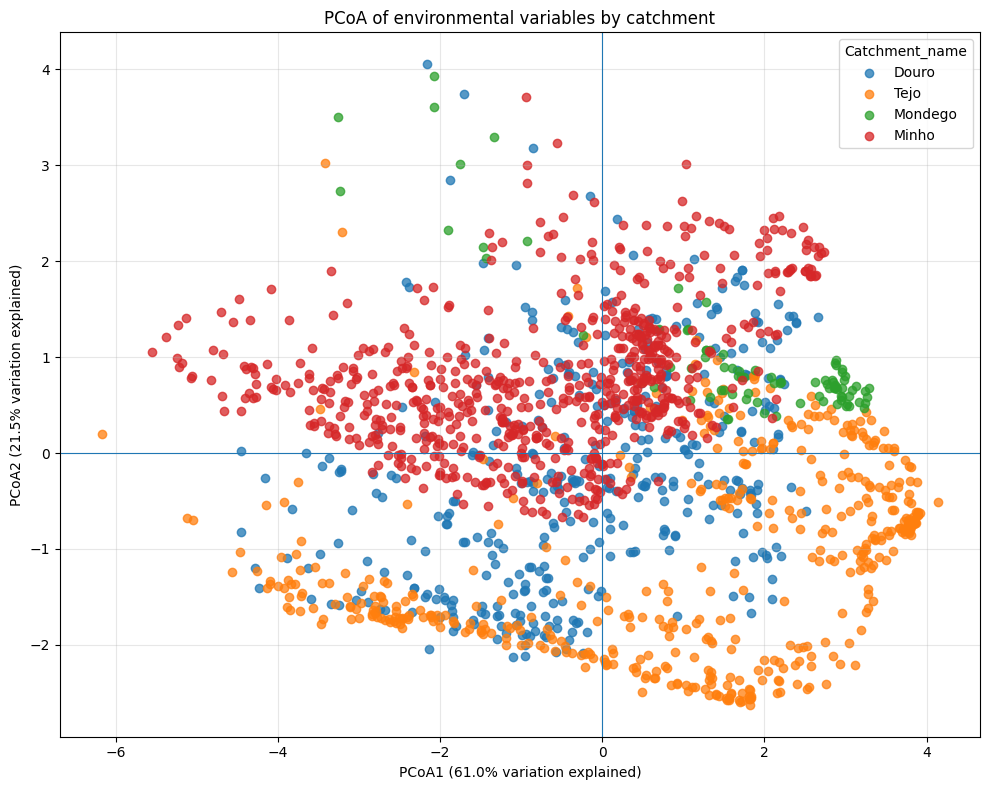

In [12]:
# PCoA plot grouped by Catchment_name.

fig, ax = plt.subplots(figsize=(10, 8))

for catchment in selected_basins:
    subset = pcoa_df[pcoa_df['Catchment_name'] == catchment]
    ax.scatter(subset['PCoA1'], subset['PCoA2'], label=catchment, alpha=0.75)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel(f"PCoA1 ({pcoa_var[0]:.1f}% variation explained)")
ax.set_ylabel(f"PCoA2 ({pcoa_var[1]:.1f}% variation explained)")
ax.set_title("PCoA of environmental variables by catchment")
ax.legend(title='Catchment_name')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pcoa_catchment.png', dpi=300, bbox_inches='tight')
plt.show()


# Part 3 — Linear Discriminant Analysis based on quantitative environmental variables

LDA is supervised: the catchment basins are used as pre-defined groups. The analysis finds linear combinations of environmental variables that maximise separation among Douro, Tejo, Mondego and Minho sites.


In [13]:
# Run LDA using Catchment_name as the pre-defined group.
# With four groups, the maximum number of discriminant axes is three.
# For the biplot, we use the first two axes.

lda = LinearDiscriminantAnalysis(n_components=2)
lda_scores = lda.fit_transform(X_scaled, y)

lda_df = pd.DataFrame(lda_scores, columns=['LD1', 'LD2'], index=data_clean.index)
lda_df['Catchment_name'] = y

lda_explained = lda.explained_variance_ratio_ * 100
print(f"LD1 explains {lda_explained[0]:.2f}% of the discriminant variance")
print(f"LD2 explains {lda_explained[1]:.2f}% of the discriminant variance")

# Coefficients indicate the contribution of each environmental variable to the discriminant axes.
lda_loadings = pd.DataFrame(
    lda.scalings_[:, :2],
    columns=['LD1', 'LD2'],
    index=env_vars
)

display(lda_loadings)


LD1 explains 90.62% of the discriminant variance
LD2 explains 5.73% of the discriminant variance


,LD1,LD2
Altitude,3.573123,-0.669434
Actual_river_slope,0.100684,-0.185863
Elevation_mean_catch,0.269917,-1.658257
prec_ann_catch,-0.490044,-0.094427
temp_ann,3.091315,-1.180445
temp_jan,1.225809,-2.280906
temp_jul,0.472179,1.013711


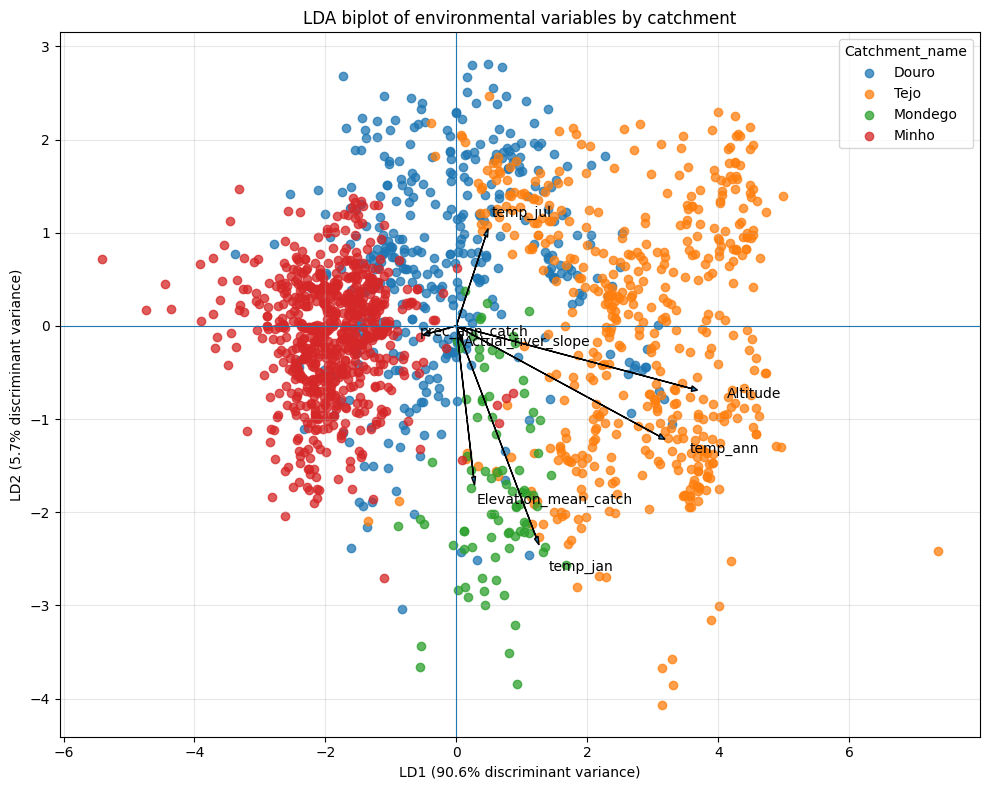

In [14]:
# LDA biplot grouped by Catchment_name.

fig, ax = plt.subplots(figsize=(10, 8))

for catchment in selected_basins:
    subset = lda_df[lda_df['Catchment_name'] == catchment]
    ax.scatter(subset['LD1'], subset['LD2'], label=catchment, alpha=0.75)

# Scale variable arrows to fit the discriminant score space.
arrow_scale_lda = min(
    (lda_df['LD1'].max() - lda_df['LD1'].min()),
    (lda_df['LD2'].max() - lda_df['LD2'].min())
) * 0.15

for var in env_vars:
    ax.arrow(
        0, 0,
        lda_loadings.loc[var, 'LD1'] * arrow_scale_lda,
        lda_loadings.loc[var, 'LD2'] * arrow_scale_lda,
        head_width=0.06,
        length_includes_head=True
    )
    ax.text(
        lda_loadings.loc[var, 'LD1'] * arrow_scale_lda * 1.12,
        lda_loadings.loc[var, 'LD2'] * arrow_scale_lda * 1.12,
        var,
        fontsize=10
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_xlabel(f"LD1 ({lda_explained[0]:.1f}% discriminant variance)")
ax.set_ylabel(f"LD2 ({lda_explained[1]:.1f}% discriminant variance)")
ax.set_title("LDA biplot of environmental variables by catchment")
ax.legend(title='Catchment_name')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lda_biplot_catchment.png', dpi=300, bbox_inches='tight')
plt.show()


## Short interpretation template

After running the notebook, use the values printed above to complete the interpretation. A possible structure is:

> The PCA biplot shows the main environmental gradients among the selected basins. Sites positioned close to one another have similar environmental conditions, while sites farther apart are more different. The arrows indicate which variables contribute most strongly to the PCA axes. Longer arrows represent variables with stronger contributions.
>
> The PCoA plot projects sites based on their Euclidean environmental distances. The grouping by `Catchment_name` allows visual assessment of whether sites from the same basin cluster together or overlap with other basins.
>
> The LDA biplot uses the basin identity as a pre-defined grouping variable. Therefore, it is expected to show clearer separation between catchments than PCA or PCoA, because LDA maximises among-group differences. Variables with larger arrows are the most important for discriminating Douro, Tejo, Mondego and Minho.
